# MazeMemory — Statistical Analysis

Compares three scenarios: Baseline, Shared Memory, Shared Memory + Observer.

**Note:** S3 has 10 runs vs 20 for S1/S2 — unequal sample sizes. Mann-Whitney handles this; statistical power for S3 is lower.

In [1]:
# ── Cell 0: Configuration — only cell you need to edit ───────────────────────
EXPERIMENT_GROUPS = {
    "Baseline": [
        "0e306b77-4a75-4358-a80c-6444760494f6",
        "f09b6974-22c7-4399-87af-0a1fe6d96cfc",
        "189cfa8d-a989-48fd-989c-d43af943de96",
        "83e52128-a9a2-4cd6-8719-b73b43c2fa3b",
        "36498e13-1270-4a12-861d-1512c4ac211d",
        "a1d155fd-6bcf-4f38-919d-b20f84c8ca7d",
        "9d36e064-65ff-40a6-afed-f0e3825566c7",
        "9d8837f4-40cc-42b6-b9c8-7c9224fd9348",
        "8d59aea2-7f44-4221-90e3-b7c0aa6a08a5",
        "b8509a00-5653-492a-b075-2e4163a08a31"
    ],
    "Shared Memory": [
        "6137ec49-5704-4775-a40f-272dd0c6ff7b",
        "30d338f3-46c8-4243-8684-37b9305e48ce",
        "968883f9-781e-4bd2-b953-3a143d96289a",
        "406cf3d7-b1ca-4fca-81da-beb43e1ebccc",
        "9cf0e3bb-7fa0-40d8-9ec5-13e21fe59e5c",
        "3a6d3716-28c7-4fdb-b889-deadab225158",
        "a585d643-24da-49cc-843d-8a5bf22cad58",
        "3179a754-593e-4124-b81e-9b0f3909e001",
        "5f94bbdc-547c-48a9-be0e-5f60021ce24f",
        "ff23b122-45c6-4f3b-89ae-a4369936f371"
    ],
    "Shared Memory + Observer": [
        "7caa2f40-dd78-46bc-8edf-9090e1ffcf30",
        "ac928ba2-a222-4192-a876-f9526502bd10",
        "8b35b983-6326-4854-a781-0fc7d34dcdb3",
        "1bfc4b65-34f0-4f8b-b690-de125fa283b8",
        "f8238c63-94a1-4409-bf0d-7cde1613eb3a",
        "9c684e08-4ee5-4bfb-adf7-3b7d4e4db6c5",
        "34e0c46d-4f58-4dd6-b966-32e7e9ab92e8",
        "651173a6-4c34-455a-a455-02dc96c510fa",
        "8465b071-e0fa-48fb-b723-64f7988bdf44",
        "43b67e9e-d75c-4fde-814a-8e8730da0cfc"
    ],
}

GROUP_ORDER = ["Baseline", "Shared Memory", "Shared Memory + Observer"]
PALETTE = {
    "Baseline":                  "#4C72B0",
    "Shared Memory":             "#DD8452",
    "Shared Memory + Observer":  "#55A868",
}

In [2]:
# ── Cell 1: Imports & Supabase connection ─────────────────────────────────────
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from supabase import create_client
from dotenv import load_dotenv

sys.path.insert(0, "..")
from src.maze.generator import generate_maze
from src.metrics.calculator import RedundantComputationReduction

load_dotenv("../.env")
sb = create_client(os.environ["SUPABASE_URL"], os.environ["SUPABASE_KEY"])
print("Connected to Supabase")

Connected to Supabase


In [3]:
# ── Cell 2: Fetch experiments + agent_runs ────────────────────────────────────
all_ids = [uid for ids in EXPERIMENT_GROUPS.values() for uid in ids]
id_to_group = {uid: grp for grp, ids in EXPERIMENT_GROUPS.items() for uid in ids}

exp_resp = (
    sb.table("experiments")
    .select("id, scenario, maze_id, maze_seed, run_number, model, "
            "total_tokens, total_prompt_tokens, total_completion_tokens, "
            "total_cache_hit_tokens, observer_prompt_tokens, "
            "observer_completion_tokens, cost_total_usd, duration_seconds")
    .in_("id", all_ids)
    .execute()
)
df_exp = pd.DataFrame(exp_resp.data)
df_exp["group"] = df_exp["id"].map(id_to_group)

ar_resp = (
    sb.table("agent_runs")
    .select("experiment_id, agent_id, steps, optimal_steps, optimality_ratio, total_tokens, reached_exit")
    .in_("experiment_id", all_ids)
    .execute()
)
df_ar = pd.DataFrame(ar_resp.data)
df_ar["group"] = df_ar["experiment_id"].map(id_to_group)

print("Experiments per group:")
print(df_exp.groupby("group")["id"].count().reindex(GROUP_ORDER))

Experiments per group:
group
Baseline                    10
Shared Memory               10
Shared Memory + Observer    10
Name: id, dtype: int64


In [4]:
# ── Cell 3: Fetch trajectories & compute RCR ──────────────────────────────────
# Supabase returns max 1000 rows per query — paginate to get all trajectories.
def fetch_all(table, select, filters):
    rows, page_size, offset = [], 1000, 0
    while True:
        q = sb.table(table).select(select)
        for col, vals in filters.items():
            q = q.in_(col, vals)
        batch = q.range(offset, offset + page_size - 1).execute().data
        rows.extend(batch)
        if len(batch) < page_size:
            break
        offset += page_size
    return rows

traj_rows = fetch_all("trajectories",
                       "experiment_id, agent_id, x, y, timestep",
                       {"experiment_id": all_ids})
df_traj = pd.DataFrame(traj_rows)
print(f"Trajectory rows loaded: {len(df_traj):,}")

rcr_rows = []
for exp_id, grp_traj in df_traj.groupby("experiment_id"):
    exp_row = df_exp[df_exp["id"] == exp_id].iloc[0]
    maze    = generate_maze(int(exp_row["maze_seed"]))
    calc    = RedundantComputationReduction(maze)

    agents_for_run = []
    for agent_id, ag_traj in grp_traj.groupby("agent_id"):
        path   = ag_traj.sort_values("timestep")[["x", "y"]].values.tolist()
        ar_row = df_ar[(df_ar["experiment_id"] == exp_id) & (df_ar["agent_id"] == agent_id)]
        reached = bool(ar_row["reached_exit"].values[0]) if len(ar_row) else False
        agents_for_run.append({"agent_id": agent_id, "path": path,
                                "reached_exit": reached, "steps": len(path) - 1})

    for r in calc.compute({"agents": agents_for_run}):
        rcr_rows.append({
            "experiment_id":       exp_id,
            "group":               id_to_group[exp_id],
            "agent_id":            r["agent_id"],
            "redundant_cells":     r["redundant_cells"],
            "total_cells_visited": r["total_cells_visited"],
            "rcr_ratio":           r["ratio"],
        })

df_rcr = pd.DataFrame(rcr_rows)
print(f"RCR rows: {len(df_rcr)}")

Trajectory rows loaded: 5,386
RCR rows: 90


In [5]:
# ── Cell 4: Build per-run DataFrames ─────────────────────────────────────────
finishers = df_ar[df_ar["reached_exit"]].copy()

por_run = (
    finishers
    .groupby(["group", "experiment_id"])
    .apply(lambda g: pd.Series({
        "fleet_por":      g["steps"].sum() / g["optimal_steps"].sum(),
        "mean_agent_por": g["optimality_ratio"].mean(),
        "n_agents":       len(g),
    }))
    .reset_index()
)

tok_run = df_exp[["group", "id", "total_tokens",
                   "total_prompt_tokens", "total_completion_tokens",
                   "observer_prompt_tokens", "observer_completion_tokens",
                   "cost_total_usd"]].copy().rename(columns={"id": "experiment_id"})
tok_run["obs_tokens"] = tok_run["observer_prompt_tokens"].fillna(0) + tok_run["observer_completion_tokens"].fillna(0)
tok_run["nav_tokens"] = tok_run["total_tokens"] - tok_run["obs_tokens"]

rcr_run = (
    df_rcr.dropna(subset=["rcr_ratio"])
    .groupby(["group", "experiment_id"])
    .apply(lambda g: pd.Series({
        "fleet_rcr":      g["redundant_cells"].sum() / g["total_cells_visited"].sum(),
        "mean_agent_rcr": g["rcr_ratio"].mean(),
    }))
    .reset_index()
)

exit_rate = (
    df_ar.groupby(["group", "experiment_id"])["reached_exit"]
    .mean()
    .reset_index(name="exit_rate")
)

print("Runs per group (POR):")
print(por_run.groupby("group")["experiment_id"].count().reindex(GROUP_ORDER))

Runs per group (POR):
group
Baseline                    10
Shared Memory               10
Shared Memory + Observer    10
Name: experiment_id, dtype: int64


In [6]:
# ── Cell 5: Descriptive statistics ───────────────────────────────────────────
def describe(df, col):
    return (
        df.groupby("group")[col]
        .agg(n="count", mean="mean", std="std", median="median",
             q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
        .reindex(GROUP_ORDER)
        .round(4)
    )

print("=== Path Optimality Ratio — fleet (PRIMARY) ===")
print(describe(por_run, "fleet_por"))
print("\n=== Path Optimality Ratio — mean of agents (secondary) ===")
print(describe(por_run, "mean_agent_por"))
print("\n=== Navigator Tokens / run — fair cross-scenario ===")
print(describe(tok_run, "nav_tokens"))
print("\n=== Observer Tokens / run (S3 only) ===")
print(describe(tok_run, "obs_tokens"))
print("\n=== Total Tokens / run ===")
print(describe(tok_run, "total_tokens"))
print("\n=== Redundant Computation Ratio — fleet (PRIMARY) ===")
print(describe(rcr_run, "fleet_rcr"))
print("\n=== Redundant Computation Ratio — mean of agents (secondary) ===")
print(describe(rcr_run, "mean_agent_rcr"))
print("\n=== Exit Rate ===")
print(describe(exit_rate, "exit_rate"))

er_s1 = exit_rate.loc[exit_rate["group"] == "Baseline",                "exit_rate"].values
er_s2 = exit_rate.loc[exit_rate["group"] == "Shared Memory",           "exit_rate"].values
er_s3 = exit_rate.loc[exit_rate["group"] == "Shared Memory + Observer","exit_rate"].values
_, p_er_s2 = mannwhitneyu(er_s2, er_s1, alternative="greater")
_, p_er_s3 = mannwhitneyu(er_s3, er_s1, alternative="greater")
print(f"\nExit rate S2 > S1: p={p_er_s2:.4f} {'✓' if p_er_s2 < 0.05 else '✗'}")
print(f"Exit rate S3 > S1: p={p_er_s3:.4f} {'✓' if p_er_s3 < 0.05 else '✗'}")
print("Note: if exit rates differ, POR comparisons are biased (only finishers counted)")

=== Path Optimality Ratio — fleet (PRIMARY) ===
                           n    mean     std  median     q25     q75
group                                                               
Baseline                  10  1.3318  0.2440  1.2045  1.1553  1.5038
Shared Memory             10  1.3205  0.1637  1.2576  1.2179  1.3712
Shared Memory + Observer  10  1.4200  0.1270  1.4470  1.3529  1.5265

=== Path Optimality Ratio — mean of agents (secondary) ===
                           n    mean     std  median     q25     q75
group                                                               
Baseline                  10  1.4168  0.3579  1.2372  1.1578  1.5637
Shared Memory             10  1.2611  0.1316  1.2372  1.1597  1.3255
Shared Memory + Observer  10  1.4566  0.2342  1.3898  1.3279  1.5825

=== Navigator Tokens / run — fair cross-scenario ===
                           n       mean          std     median        q25  \
group                                                                 

/tmp/ipykernel_44918/1393437379.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="group", y=col, order=GROUP_ORDER, palette=PALETTE, ax=ax)
/tmp/ipykernel_44918/1393437379.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Baseline", "Shared\nMemory", "Shared Mem\n+ Observer"], rotation=0)
/tmp/ipykernel_44918/1393437379.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="group", y=col, order=GROUP_ORDER, palette=PALETTE, ax=ax)
/tmp/ipykernel_44918/1393437379.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after se

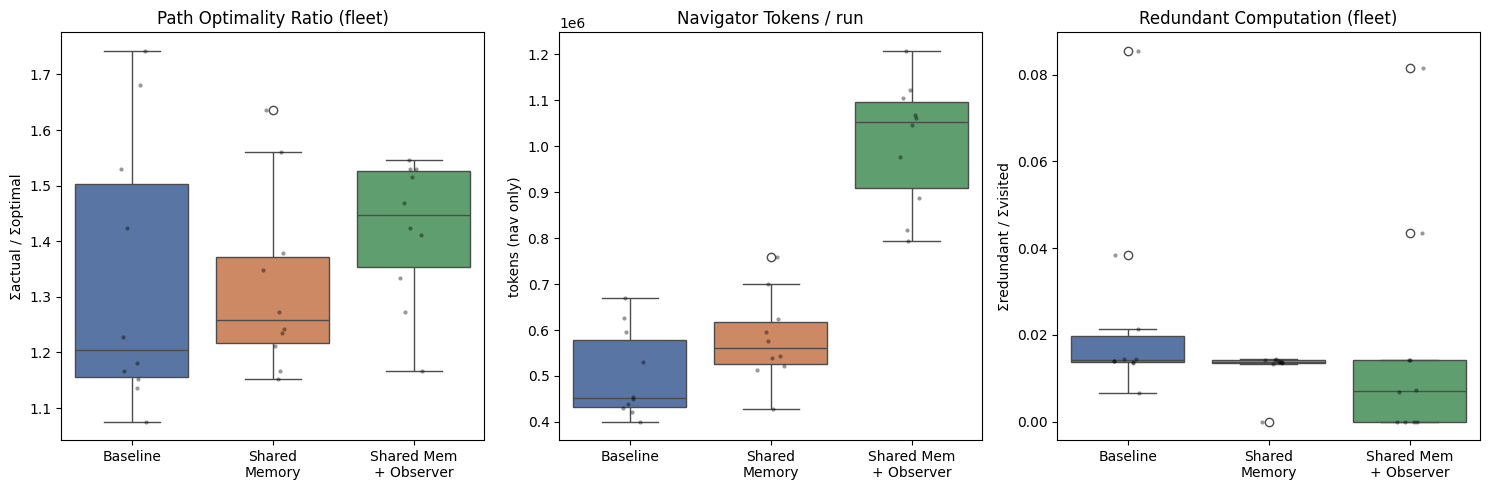

In [7]:
# ── Cell 6: Main boxplots (3 primary metrics) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (df, col, title, ylabel) in zip(axes, [
    (por_run, "fleet_por",  "Path Optimality Ratio (fleet)",  "Σactual / Σoptimal"),
    (tok_run, "nav_tokens", "Navigator Tokens / run",         "tokens (nav only)"),
    (rcr_run, "fleet_rcr",  "Redundant Computation (fleet)",  "Σredundant / Σvisited"),
]):
    sns.boxplot(data=df, x="group", y=col, order=GROUP_ORDER, palette=PALETTE, ax=ax)
    sns.stripplot(data=df, x="group", y=col, order=GROUP_ORDER,
                  color="black", size=3, alpha=0.4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(["Baseline", "Shared\nMemory", "Shared Mem\n+ Observer"], rotation=0)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150)
plt.show()

                          nav_tokens  obs_tokens  total_tokens
group                                                         
Baseline                    501681.0         0.0      501681.0
Shared Memory               580024.0         0.0      580024.0
Shared Memory + Observer   1008552.0     20989.0     1029542.0


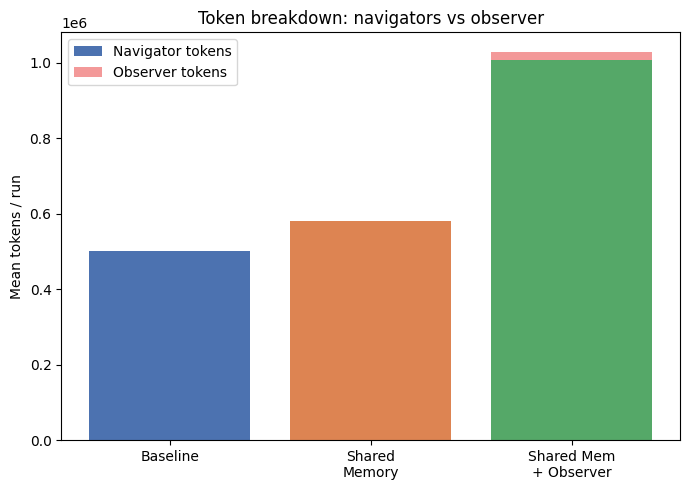


S2 navigator saving vs S1: -78343 tokens (-15.6%)
S3 navigator saving vs S1: -506871 tokens (-101.0%)
S3 observer overhead:      20989 tokens/run
S3 net vs S1:              +527860 tokens/run

Nav tokens S2 < S1: p=0.9479 ✗
Nav tokens S3 < S1: p=0.9999 ✗


In [8]:
# ── Cell 6b: Token breakdown — navigator vs observer ──────────────────────────
tok_breakdown = (
    tok_run.groupby("group")[["nav_tokens", "obs_tokens", "total_tokens"]]
    .mean().reindex(GROUP_ORDER).round(0)
)
print(tok_breakdown)

fig, ax = plt.subplots(figsize=(7, 5))
nav = tok_breakdown["nav_tokens"]
obs = tok_breakdown["obs_tokens"]
x   = range(len(GROUP_ORDER))
ax.bar(x, nav, color=[PALETTE[g] for g in GROUP_ORDER], label="Navigator tokens")
ax.bar(x, obs, bottom=nav, color="lightcoral", alpha=0.8, label="Observer tokens")
ax.set_xticks(x)
ax.set_xticklabels(["Baseline", "Shared\nMemory", "Shared Mem\n+ Observer"])
ax.set_ylabel("Mean tokens / run")
ax.set_title("Token breakdown: navigators vs observer")
ax.legend()
plt.tight_layout()
plt.savefig("token_breakdown.png", dpi=150)
plt.show()

s1_nav = tok_run.loc[tok_run["group"] == "Baseline",                "nav_tokens"].values
s2_nav = tok_run.loc[tok_run["group"] == "Shared Memory",           "nav_tokens"].values
s3_nav = tok_run.loc[tok_run["group"] == "Shared Memory + Observer","nav_tokens"].values
s3_obs = tok_run.loc[tok_run["group"] == "Shared Memory + Observer","obs_tokens"].values
s3_tot = tok_run.loc[tok_run["group"] == "Shared Memory + Observer","total_tokens"].values
s1_tot = tok_run.loc[tok_run["group"] == "Baseline",                "total_tokens"].values

print(f"\nS2 navigator saving vs S1: {s1_nav.mean()-s2_nav.mean():.0f} tokens ({(1-s2_nav.mean()/s1_nav.mean())*100:.1f}%)")
print(f"S3 navigator saving vs S1: {s1_nav.mean()-s3_nav.mean():.0f} tokens ({(1-s3_nav.mean()/s1_nav.mean())*100:.1f}%)")
print(f"S3 observer overhead:      {s3_obs.mean():.0f} tokens/run")
print(f"S3 net vs S1:              {s3_tot.mean()-s1_tot.mean():+.0f} tokens/run")

_, p_s2_nav = mannwhitneyu(s2_nav, s1_nav, alternative="less")
_, p_s3_nav = mannwhitneyu(s3_nav, s1_nav, alternative="less")
print(f"\nNav tokens S2 < S1: p={p_s2_nav:.4f} {'✓' if p_s2_nav < 0.05 else '✗'}")
print(f"Nav tokens S3 < S1: p={p_s3_nav:.4f} {'✓' if p_s3_nav < 0.05 else '✗'}")

In [9]:
# ── Cell 7: 95% Bootstrap Confidence Intervals ───────────────────────────────
def bootstrap_ci(x, n_boot=10_000, ci=0.95):
    x = np.asarray(x, dtype=float)
    boot = np.random.choice(x, (n_boot, len(x)), replace=True).mean(axis=1)
    return np.percentile(boot, [(1-ci)/2*100, (1+ci)/2*100])

ci_rows = []
for label, df_m, col in [
    ("POR (fleet)",  por_run, "fleet_por"),
    ("Nav Tokens",   tok_run, "nav_tokens"),
    ("RCR (fleet)",  rcr_run, "fleet_rcr"),
]:
    for grp in GROUP_ORDER:
        vals = df_m.loc[df_m["group"] == grp, col].dropna().values
        lo, hi = bootstrap_ci(vals)
        ci_rows.append({"Metric": label, "Group": grp,
                        "Mean": round(vals.mean(), 4),
                        "CI_low": round(lo, 4), "CI_high": round(hi, 4), "n": len(vals)})

pd.DataFrame(ci_rows).to_markdown(index=False)

'| Metric      | Group                    |             Mean |      CI_low |          CI_high |   n |\n|:------------|:-------------------------|-----------------:|------------:|-----------------:|----:|\n| POR (fleet) | Baseline                 |      1.3318      |      1.197  |      1.4818      |  10 |\n| POR (fleet) | Shared Memory            |      1.3205      |      1.2327 |      1.4258      |  10 |\n| POR (fleet) | Shared Memory + Observer |      1.42        |      1.3412 |      1.4894      |  10 |\n| Nav Tokens  | Baseline                 | 501681           | 447910      | 560539           |  10 |\n| Nav Tokens  | Shared Memory            | 580024           | 527194      | 639298           |  10 |\n| Nav Tokens  | Shared Memory + Observer |      1.00855e+06 | 927576      |      1.08588e+06 |  10 |\n| RCR (fleet) | Baseline                 |      0.0236      |      0.0133 |      0.0388      |  10 |\n| RCR (fleet) | Shared Memory            |      0.0125      |      0.0096 |      

In [10]:
# ── Cell 8: Normality check (Shapiro-Wilk) ───────────────────────────────────
print("Shapiro-Wilk  (p > 0.05 → cannot reject normality)\n")
for label, df_m, col in [
    ("POR (fleet)", por_run, "fleet_por"),
    ("Nav Tokens",  tok_run, "nav_tokens"),
    ("RCR (fleet)", rcr_run, "fleet_rcr"),
]:
    print(f"  {label}")
    for grp in GROUP_ORDER:
        vals = df_m.loc[df_m["group"] == grp, col].dropna().values
        stat, p = shapiro(vals)
        flag = "✓ normal" if p > 0.05 else "✗ non-normal"
        print(f"    {grp:35s}  W={stat:.4f}  p={p:.4f}  {flag}")

Shapiro-Wilk  (p > 0.05 → cannot reject normality)

  POR (fleet)
    Baseline                             W=0.8539  p=0.0647  ✓ normal
    Shared Memory                        W=0.8719  p=0.1052  ✓ normal
    Shared Memory + Observer             W=0.8874  p=0.1586  ✓ normal
  Nav Tokens
    Baseline                             W=0.8591  p=0.0744  ✓ normal
    Shared Memory                        W=0.9590  p=0.7745  ✓ normal
    Shared Memory + Observer             W=0.9347  p=0.4954  ✓ normal
  RCR (fleet)
    Baseline                             W=0.6209  p=0.0001  ✗ non-normal
    Shared Memory                        W=0.4422  p=0.0000  ✗ non-normal
    Shared Memory + Observer             W=0.6965  p=0.0008  ✗ non-normal


In [11]:
# ── Cell 9: Hypothesis tests (Welch t + Mann-Whitney, one-tailed) ─────────────
# H1: treatment < baseline (lower is better for all three metrics)

def get_vals(df_m, col, grp):
    return df_m.loc[df_m["group"] == grp, col].dropna().values

raw_p_welch, raw_p_mw, test_labels = [], [], []

for label, df_m, col in [
    ("POR (fleet)", por_run, "fleet_por"),
    ("Nav Tokens",  tok_run, "nav_tokens"),
    ("RCR (fleet)", rcr_run, "fleet_rcr"),
]:
    bl = get_vals(df_m, col, "Baseline")
    for treatment in ["Shared Memory", "Shared Memory + Observer"]:
        tr = get_vals(df_m, col, treatment)
        t, p_two = ttest_ind(tr, bl, equal_var=False)
        p_welch  = p_two / 2 if t < 0 else 1 - p_two / 2
        _, p_mw  = mannwhitneyu(tr, bl, alternative="less")
        lbl = f"{label} | {treatment} vs Baseline"
        raw_p_welch.append(p_welch)
        raw_p_mw.append(p_mw)
        test_labels.append(lbl)
        print(f"{lbl}")
        print(f"  Welch t  t={t:.3f}  p(one-tail)={p_welch:.4f}")
        print(f"  Mann-Wh  p(one-tail)={p_mw:.4f}\n")

POR (fleet) | Shared Memory vs Baseline
  Welch t  t=-0.122  p(one-tail)=0.4523
  Mann-Wh  p(one-tail)=0.7148

POR (fleet) | Shared Memory + Observer vs Baseline
  Welch t  t=1.013  p(one-tail)=0.8357
  Mann-Wh  p(one-tail)=0.8799

Nav Tokens | Shared Memory vs Baseline
  Welch t  t=1.825  p(one-tail)=0.9577
  Mann-Wh  p(one-tail)=0.9479

Nav Tokens | Shared Memory + Observer vs Baseline
  Welch t  t=9.584  p(one-tail)=1.0000
  Mann-Wh  p(one-tail)=0.9999

RCR (fleet) | Shared Memory vs Baseline
  Welch t  t=-1.485  p(one-tail)=0.0848
  Mann-Wh  p(one-tail)=0.0603

RCR (fleet) | Shared Memory + Observer vs Baseline
  Welch t  t=-0.617  p(one-tail)=0.2727
  Mann-Wh  p(one-tail)=0.0694



In [12]:
# ── Cell 10: Multiple-comparison correction (Benjamini-Hochberg) ──────────────
_, p_bh_welch, _, _ = multipletests(raw_p_welch, method="fdr_bh")
_, p_bh_mw,    _, _ = multipletests(raw_p_mw,    method="fdr_bh")

print(f"{'Test':<50}  {'Welch raw':>10}  {'BH':>7}  {'MW raw':>8}  {'BH':>7}  sig(MW)?")
print("-" * 100)
for lbl, rw, bw, rm, bm in zip(test_labels, raw_p_welch, p_bh_welch, raw_p_mw, p_bh_mw):
    sig = "✓" if bm < 0.05 else "✗"
    print(f"{lbl:<50}  {rw:>10.4f}  {bw:>7.4f}  {rm:>8.4f}  {bm:>7.4f}  {sig}")

Test                                                 Welch raw       BH    MW raw       BH  sig(MW)?
----------------------------------------------------------------------------------------------------
POR (fleet) | Shared Memory vs Baseline                 0.4523   0.9046    0.7148   0.9999  ✗
POR (fleet) | Shared Memory + Observer vs Baseline      0.8357   1.0000    0.8799   0.9999  ✗
Nav Tokens | Shared Memory vs Baseline                  0.9577   1.0000    0.9479   0.9999  ✗
Nav Tokens | Shared Memory + Observer vs Baseline       1.0000   1.0000    0.9999   0.9999  ✗
RCR (fleet) | Shared Memory vs Baseline                 0.0848   0.5086    0.0603   0.2082  ✗
RCR (fleet) | Shared Memory + Observer vs Baseline      0.2727   0.8180    0.0694   0.2082  ✗


In [13]:
# ── Cell 11: Effect size (Cohen's d) ─────────────────────────────────────────
def cohens_d(a, b):
    n_a, n_b = len(a), len(b)
    sp = np.sqrt(((n_a-1)*np.var(a, ddof=1) + (n_b-1)*np.var(b, ddof=1)) / (n_a+n_b-2))
    return (np.mean(a) - np.mean(b)) / sp  # negative = treatment improved

print(f"{'Metric':<14}  {'Comparison':<35}  {'d':>7}  magnitude")
print("-" * 70)
for label, df_m, col in [
    ("POR (fleet)",  por_run, "fleet_por"),
    ("Nav Tokens",   tok_run, "nav_tokens"),
    ("RCR (fleet)",  rcr_run, "fleet_rcr"),
]:
    bl = get_vals(df_m, col, "Baseline")
    for treatment in ["Shared Memory", "Shared Memory + Observer"]:
        tr  = get_vals(df_m, col, treatment)
        d   = cohens_d(tr, bl)
        mag = ("negligible" if abs(d) < 0.2 else
               "small"      if abs(d) < 0.5 else
               "medium"     if abs(d) < 0.8 else "large")
        print(f"{label:<14}  {treatment:<35}  {d:>7.3f}  {mag}")

Metric          Comparison                                 d  magnitude
----------------------------------------------------------------------
POR (fleet)     Shared Memory                         -0.054  negligible
POR (fleet)     Shared Memory + Observer               0.453  small
Nav Tokens      Shared Memory                          0.816  large
Nav Tokens      Shared Memory + Observer               4.286  large
RCR (fleet)     Shared Memory                         -0.664  medium
RCR (fleet)     Shared Memory + Observer              -0.276  small


In [14]:
# ── Cell 12: Summary table ───────────────────────────────────────────────────
# Q1: Is Shared Memory (S2) better than Baseline?
# Q2: Is Shared Memory + Observer (S3) better than Baseline?
# Lower is better for all three metrics.

rows = []
for label, df_m, col, idx in [
    ("Path Optimality (POR)", por_run, "fleet_por",  0),
    ("Navigator Tokens",      tok_run, "nav_tokens", 2),
    ("Redundant Work (RCR)",  rcr_run, "fleet_rcr",  4),
]:
    bl_m = get_vals(df_m, col, "Baseline").mean()
    for i, (treatment, short) in enumerate([
        ("Shared Memory",            "S2"),
        ("Shared Memory + Observer", "S3"),
    ]):
        tr_m    = get_vals(df_m, col, treatment).mean()
        pct     = (tr_m - bl_m) / bl_m * 100
        bm      = p_bh_mw[idx + i]
        verdict = "✓ better" if pct < -5 else ("✗ worse" if pct > 5 else "≈ same")
        rows.append({
            "Metric":    label,
            "Scenario":  short,
            "Baseline":  round(bl_m, 4),
            "Value":     round(tr_m, 4),
            "Change":    f"{pct:+.1f}%",
            "Result":    verdict,
            "p(BH)":     round(bm, 3),
            "Sig?":      "✓ yes" if bm < 0.05 else "✗ no",
        })

pd.set_option("display.max_colwidth", None)
display(pd.DataFrame(rows))

,Metric,Scenario,Baseline,Value,Change,Result,p(BH),Sig?
0,Path Optimality (POR),S2,1.3318,1.320500e+00,-0.8%,≈ same,1.000,✗ no
1,Path Optimality (POR),S3,1.3318,1.420000e+00,+6.6%,✗ worse,1.000,✗ no
2,Navigator Tokens,S2,501681.3000,5.800244e+05,+15.6%,✗ worse,1.000,✗ no
3,Navigator Tokens,S3,501681.3000,1.008552e+06,+101.0%,✗ worse,1.000,✗ no
4,Redundant Work (RCR),S2,0.0236,1.250000e-02,-47.2%,✓ better,0.208,✗ no
5,Redundant Work (RCR),S3,0.0236,1.680000e-02,-29.0%,✓ better,0.208,✗ no
